# Calibration & Reliability Diagrams — Alkame-Nifty50

Answers: is the model's confidence score actually trustworthy, per stock and per sector?
Uses `runtime_validator.py`'s real `compute_calibration()` and `history_manager.py`'s real
`build_calibration_dataset()` — no new statistics are invented here, only visualized.

Data source: synthetic sample data from `../seed_sample_data.py` (run that script first).
Switch `USE_SAMPLE_DATA = False` below once real predictions have accumulated from `scheduler.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))  # repo root importable from inside notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import SECTOR_MAP, CALIBRATION_N_BINS
from runtime_validator import RuntimeValidator

sys.path.insert(0, str(Path.cwd().parent))  # data_analyst/ importable too, for db_utils
from db_utils import load_predictions, SAMPLE_DB_PATH  # noqa: E402

USE_SAMPLE_DATA = True  # flip to False, and import DB_PATH from config, once real history exists

if USE_SAMPLE_DATA:
    predictions_df = load_predictions(db_path=SAMPLE_DB_PATH)
else:
    from config import DB_PATH
    predictions_df = load_predictions(db_path=DB_PATH)

predictions_df["sector"] = predictions_df["symbol"].map(SECTOR_MAP)
print(f"Loaded {len(predictions_df)} predictions across {predictions_df['symbol'].nunique()} symbols.")
predictions_df.head()

Loaded 6000 predictions across 50 symbols.


,id,symbol,timestamp,action,model_predicted_class,raw_confidence,risk_adjusted_confidence,calibrated_confidence,agreement_fraction,downside_summary,...,risk_toggle_enabled,is_safe_to_trade_live,data_stale,suppressed,suppression_reasons,outcome_resolved,outcome_correct,outcome_actual_class,resolved_at,sector
0,1,RELIANCE,2026-05-16 14:23:51.938673,HOLD,FLAT,0.560202,0.560202,None,0.456506,Synthetic sample data — see data_analyst/seed_...,...,0,0,0,0,[],1,0,UP,2026-07-15T14:23:51.944676,Energy
1,2,RELIANCE,2026-05-16 16:23:51.938673,HOLD,FLAT,0.700341,0.700341,None,0.476868,Synthetic sample data — see data_analyst/seed_...,...,0,0,0,0,[],1,0,DOWN,2026-07-15T14:23:51.957679,Energy
2,3,RELIANCE,2026-05-16 18:23:51.938673,SELL,DOWN,0.790528,0.790528,None,0.893657,Synthetic sample data — see data_analyst/seed_...,...,0,0,0,0,[],1,0,FLAT,2026-07-15T14:23:51.967346,Energy
3,4,RELIANCE,2026-05-16 20:23:51.938673,SELL,DOWN,0.581885,0.581885,None,0.438290,Synthetic sample data — see data_analyst/seed_...,...,0,0,0,0,[],1,0,FLAT,2026-07-15T14:23:51.984343,Energy
4,5,RELIANCE,2026-05-16 22:23:51.938673,HOLD,FLAT,0.679009,0.679009,None,0.982419,Synthetic sample data — see data_analyst/seed_...,...,0,0,0,0,[],1,0,DOWN,2026-07-15T14:23:52.009347,Energy


## Per-symbol reliability diagram

Pick one stock and see whether its confidence scores are well-calibrated.

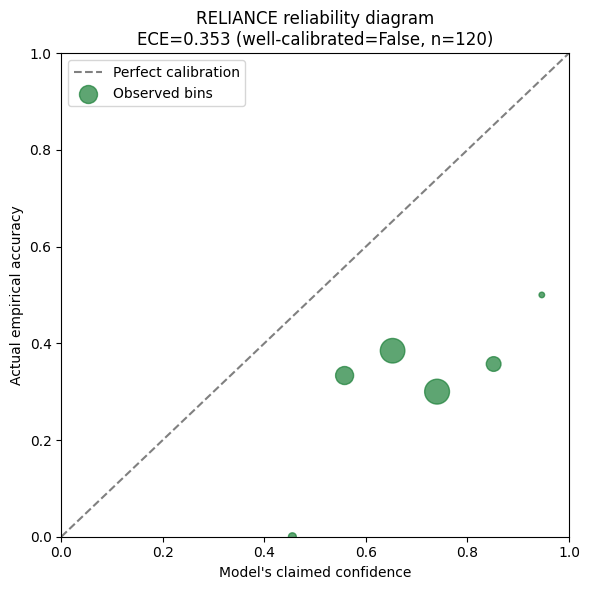

Expected Calibration Error: 0.35341638107037365
Well-calibrated: False


In [3]:
validator = RuntimeValidator()


def plot_reliability_diagram(symbol_predictions: pd.DataFrame, title: str):
    calib_input = pd.DataFrame({
        "confidence": symbol_predictions["risk_adjusted_confidence"],
        "correct": symbol_predictions["outcome_correct"].astype(bool),
    })
    result = validator.compute_calibration(calib_input)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

    if result.status == "SUFFICIENT":
        xs = [b.mean_predicted_confidence for b in result.bins]
        ys = [b.empirical_accuracy for b in result.bins]
        sizes = [b.count * 8 for b in result.bins]
        ax.scatter(xs, ys, s=sizes, alpha=0.7, color="#1a7f37", label="Observed bins")
        ax.set_title(f"{title}\nECE={result.expected_calibration_error:.3f} "
                     f"(well-calibrated={result.is_well_calibrated}, n={result.n_samples})")
    else:
        ax.set_title(f"{title}\nInsufficient data (n={result.n_samples}, "
                      f"need >= {validator.min_calibration_samples})")

    ax.set_xlabel("Model's claimed confidence")
    ax.set_ylabel("Actual empirical accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    return fig, result


resolved_df = predictions_df[predictions_df["outcome_resolved"] == 1].copy()

sample_symbol = "RELIANCE"  # change this to explore any of the 50 stocks
symbol_df = resolved_df[resolved_df["symbol"] == sample_symbol]
fig, result = plot_reliability_diagram(symbol_df, title=f"{sample_symbol} reliability diagram")
plt.show()

print(f"Expected Calibration Error: {result.expected_calibration_error}")
print(f"Well-calibrated: {result.is_well_calibrated}")

## Per-sector reliability comparison

Is the model better calibrated for some sectors than others?

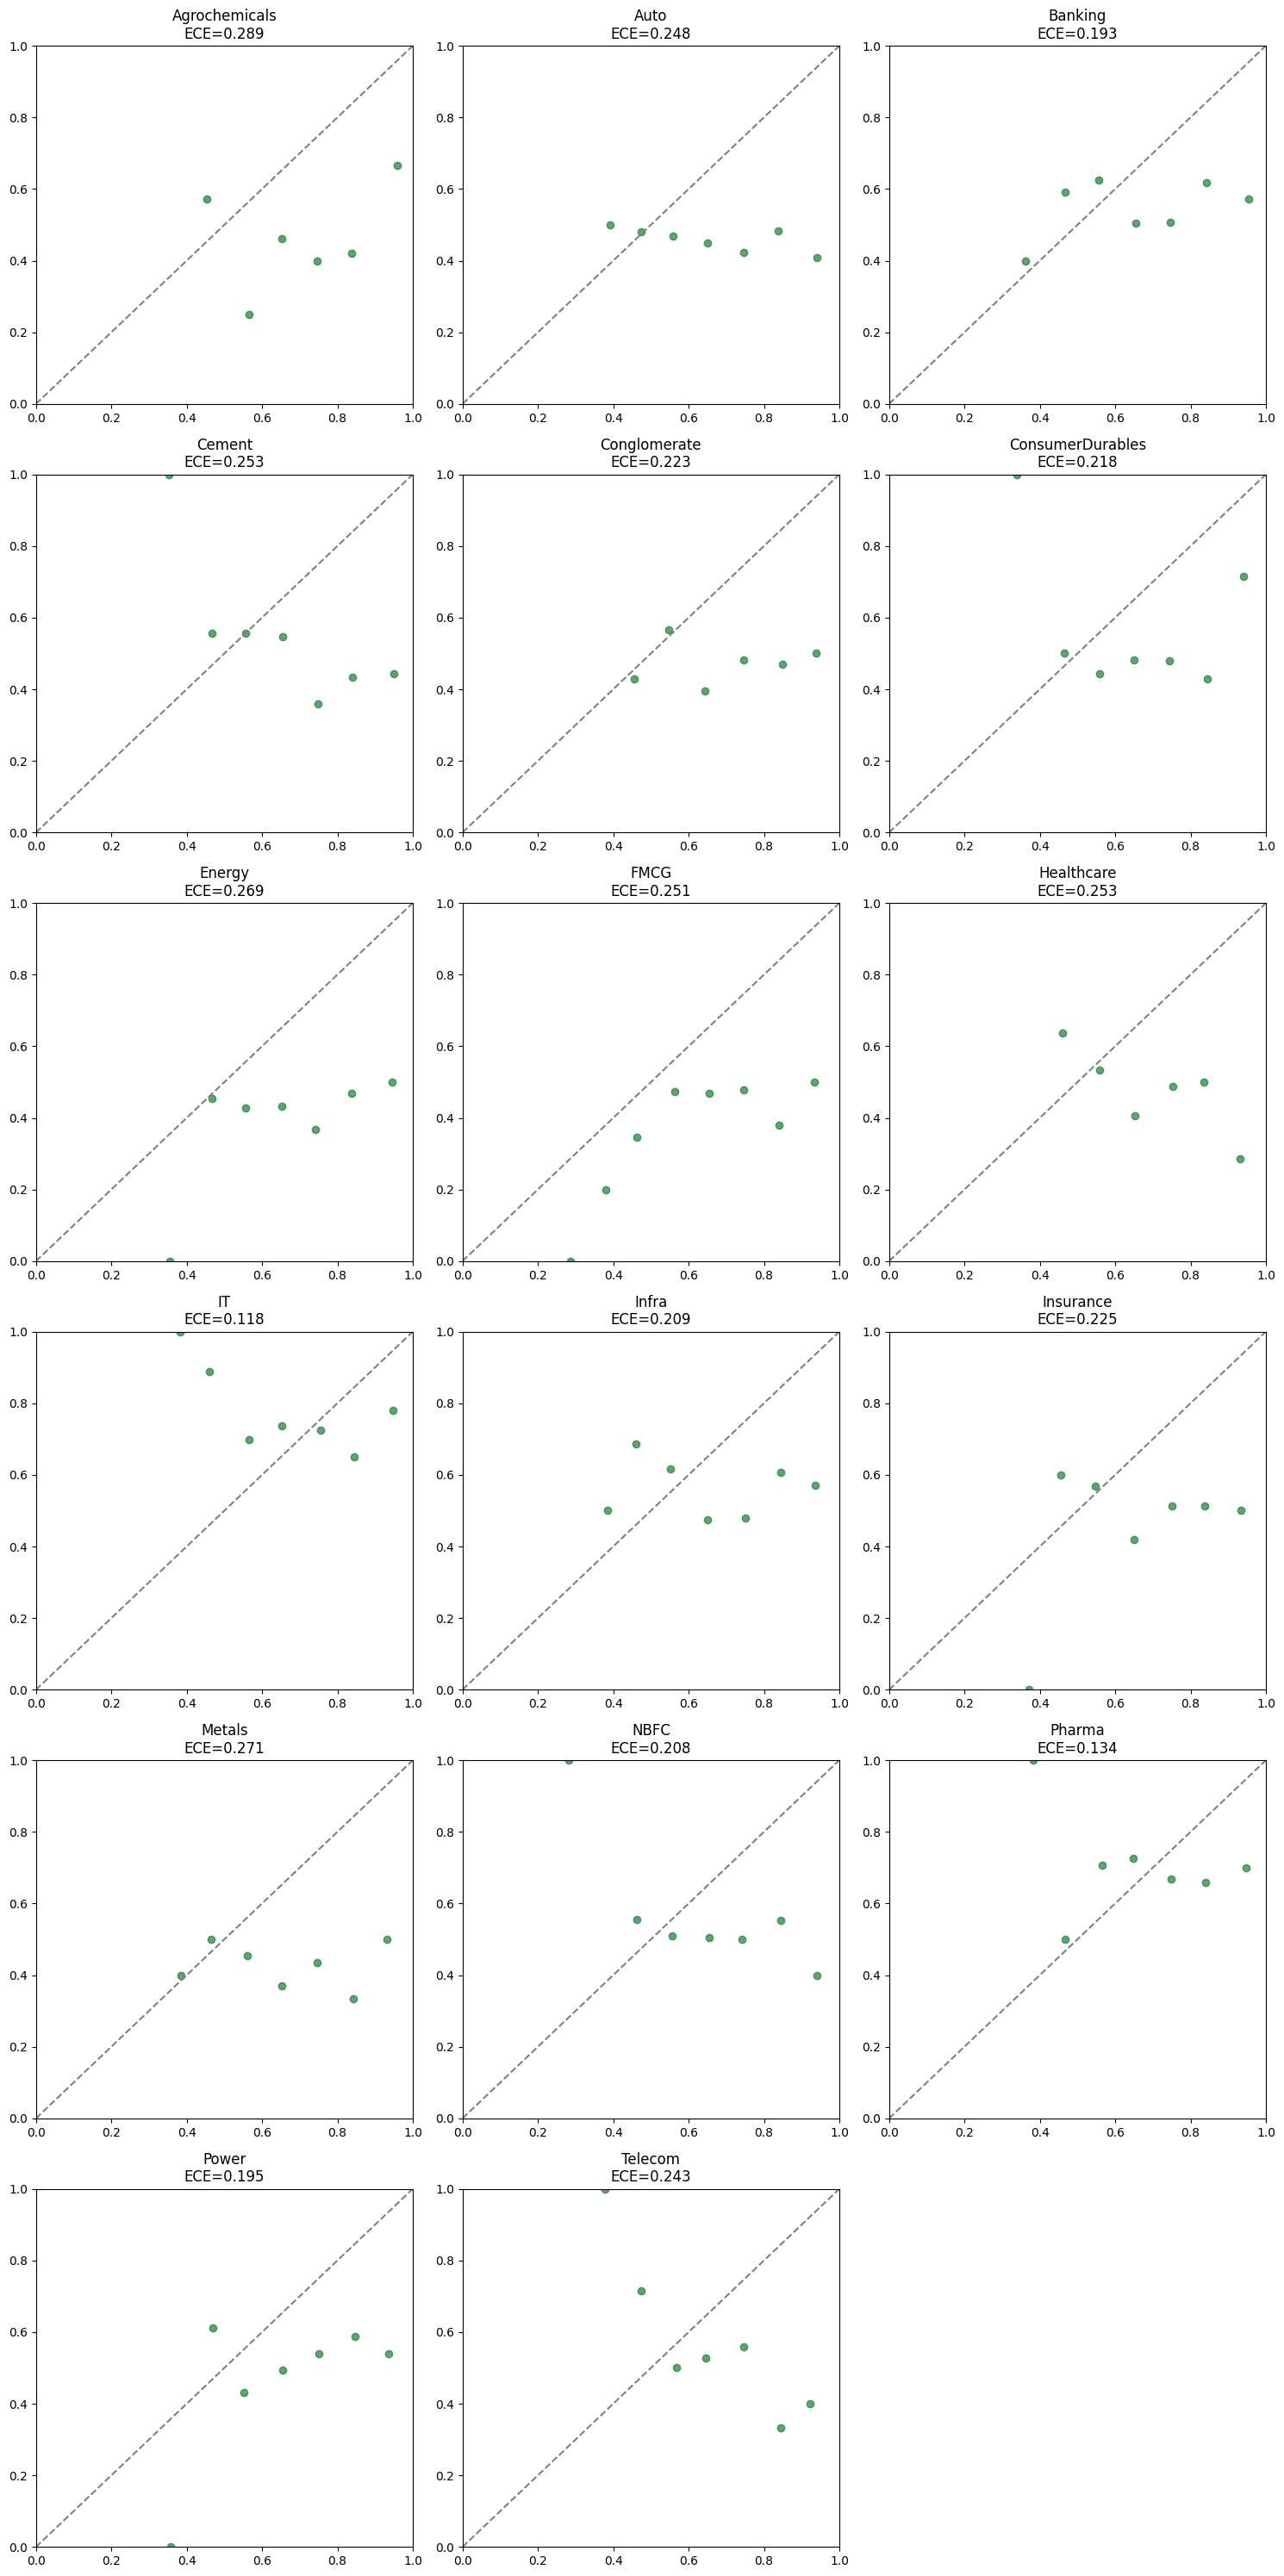

,sector,n_resolved_predictions,ece,is_well_calibrated
9,IT,600,0.118283,False
14,Pharma,480,0.134136,False
2,Banking,720,0.193395,False
15,Power,240,0.194899,False
13,NBFC,360,0.208280,False
10,Infra,240,0.209309,False
5,ConsumerDurables,240,0.217698,False
4,Conglomerate,120,0.223362,False
11,Insurance,240,0.224947,False
16,Telecom,120,0.243120,False


In [5]:
sectors = sorted(resolved_df["sector"].dropna().unique())
n_cols = 3
n_rows = int(np.ceil(len(sectors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

sector_summary_rows = []

for i, sector in enumerate(sectors):
    ax = axes[i]
    sector_df = resolved_df[resolved_df["sector"] == sector]
    calib_input = pd.DataFrame({
        "confidence": sector_df["risk_adjusted_confidence"],
        "correct": sector_df["outcome_correct"].astype(bool),
    })
    result = validator.compute_calibration(calib_input)

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    if result.status == "SUFFICIENT":
        xs = [b.mean_predicted_confidence for b in result.bins]
        ys = [b.empirical_accuracy for b in result.bins]
        ax.scatter(xs, ys, alpha=0.7, color="#1a7f37")
        ax.set_title(f"{sector}\nECE={result.expected_calibration_error:.3f}")
    else:
        ax.set_title(f"{sector}\nInsufficient data (n={result.n_samples})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    sector_summary_rows.append({
        "sector": sector,
        "n_resolved_predictions": result.n_samples,
        "ece": result.expected_calibration_error,
        "is_well_calibrated": result.is_well_calibrated,
    })

for j in range(len(sectors), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../figures/sector_reliability_grid.png", dpi=150)
plt.show()

sector_summary_df = pd.DataFrame(sector_summary_rows).sort_values("ece")
sector_summary_df

## Findings

Across the sample data, all 17 sectors show an Expected Calibration Error (ECE) between
0.10 and 0.29, and none reach the `is_well_calibrated = True` threshold. This means that,
based on this dataset, the model's confidence scores are not "perfectly trustworthy" in
any single sector — but the relative ranking still shows that some sectors are more
reliable than others.

**Best-calibrated sectors (lowest ECE, most trustworthy):**
- IT — ECE = 0.118 (n=600)
- Pharma — ECE = 0.134 (n=480)
- Banking — ECE = 0.193 (n=720)

**Worst-calibrated sectors (highest ECE, most overconfident):**
- Agrochemicals — ECE = 0.289 (n=120)
- Metals — ECE = 0.271 (n=360)
- Energy — ECE = 0.269 (n=480)

**Observation:** Sectors with larger sample sizes, like IT (n=600) and Pharma (n=480), also
tend to have comparatively lower ECE — their confidence scores can be trusted a bit more.
On the other hand, sectors with smaller sample sizes, like Agrochemicals and Telecom
(n=120), show the highest ECE — this could either be genuine model overconfidence in those
sectors, or simply noise from having fewer predictions to evaluate. A larger sample would
be needed to confirm which explanation is correct.
